# Parametric PINN Training (02 layout)

This notebook reuses the structure of **02_pinn_train.ipynb** but implements the
parametric/`ParamBC` logic from the dedicated parametric notebook.  

## Setup

In [1]:
import sys
from pathlib import Path
from dataclasses import dataclass
import json
import time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import importlib

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing /src")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))


import src.pinn
from src.utils import set_seed, get_device
from src.data import load_manifest_rows, load_case_manifest_row, ParamPINNBatch
from src.pinn import MLP, LossWeights
from src.train import train_adam, train_lbfgs

set_seed(42)
device = get_device()
print(f"Project root: {ROOT}")
print(f"Device: {device}")

MU_TIME_SAMPLES = 15

RUN_ID = datetime.now(timezone.utc).strftime("%Y_%m_%d_%H%M")
OUTDIR = ROOT / "outputs" / "parametric" / RUN_ID
OUTDIR.mkdir(parents=True, exist_ok=True)
print(f"RUN_ID: {RUN_ID}")
print(f"OUTDIR: {OUTDIR}")

Project root: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN
Device: cpu
RUN_ID: 2026_03_16_1425
OUTDIR: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1425


## Data Loading and Case Split

In [2]:
manifest = ROOT / "data" / "manifest.csv"
rows = load_manifest_rows(manifest)
if len(rows) < 2:
    raise RuntimeError("Need at least two cases for train/held-out split.")

# deterministic split; keep final 20% as held-out
rows_sorted = sorted(rows, key=lambda r: r["case_id"])
n_val_cases = max(1, int(round(0.2 * len(rows_sorted))))
val_rows = rows_sorted[-n_val_cases:]
train_rows = rows_sorted[:-n_val_cases]

if len(train_rows) == 0:
    raise RuntimeError("Split produced no training cases.")

print("Train cases:", [r["case_id"] for r in train_rows])
print("Held-out cases:", [r["case_id"] for r in val_rows])

Train cases: ['const_10000', 'const_15000', 'const_5000', 'offset_sine_1', 'sine_A10000_T100', 'sine_A10000_T50']
Held-out cases: ['sine_A5000_T100', 'sine_A5000_T50']


## Data Preprocessing and Parametric Batch

In [3]:
def compute_mu_stats(cases):
    eps = 1e-8
    all_mu = np.array([c["mu_raw"] for c in cases])
    mu_min = all_mu.min(axis=0)
    mu_max = all_mu.max(axis=0)
    return {
        "mu_min": mu_min,
        "mu_max": mu_max,
        "eps": eps,
    }


def normalise_mu(mu_raw, mu_stats):
    eps = mu_stats["eps"]
    mu_min = mu_stats["mu_min"]
    mu_max = mu_stats["mu_max"]
    return 2.0 * (mu_raw - mu_min) / (mu_max - mu_min + eps) - 1.0


def _load_case_with_mu(row: dict) -> dict:
    c = load_case_manifest_row(row, root=ROOT)

    # Conditioning uses only the informative right-boundary history.
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]

    tau_max = tau.max()
    tau_samples = np.linspace(0, tau_max, MU_TIME_SAMPLES)
    theta_series_1 = np.interp(tau_samples, tau, theta[-1, :]).astype(np.float32)
    dtheta_dtau_1 = np.gradient(theta_series_1, tau_samples).astype(np.float32)

    mu_right_raw = np.concatenate([theta_series_1, dtheta_dtau_1]).astype(np.float32)

    c["mu_raw"] = mu_right_raw
    c["mu"] = mu_right_raw  # Will be normalized later.
    return c


train_cases = [_load_case_with_mu(r) for r in train_rows]
val_cases = [_load_case_with_mu(r) for r in val_rows]

mu_stats = compute_mu_stats(train_cases)
for c in (train_cases + val_cases):
    c["mu"] = normalise_mu(c["mu_raw"], mu_stats)

print(f"Loaded {len(train_cases)} train cases and {len(val_cases)} held-out cases.")
print("mu_stats min:", mu_stats["mu_min"][:5], "...")
print("mu_stats max:", mu_stats["mu_max"][:5], "...")

if train_cases:
    print("Example mu_right:", train_cases[0]["mu"][:5], "...")

all_mu = np.stack([c["mu"] for c in (train_cases + val_cases)], axis=0)
print("mu_vector mins:", all_mu.min(axis=0)[:5], "...")
print("mu_vector maxs:", all_mu.max(axis=0)[:5], "...")


Loaded 6 train cases and 2 held-out cases.
mu_stats min: [ 0.         -0.3571001  -0.50471044 -0.72004795 -0.924139  ] ...
mu_stats max: [ 0.         -0.06587804 -0.18317512 -0.32647806 -0.48052007] ...
Example mu_right: [-1.         -1.         -0.9999952  -0.46575975  0.00385547] ...
mu_vector mins: [-1. -1. -1. -1. -1.] ...
mu_vector maxs: [-1.         1.         1.         1.0000143  1.0000124] ...


In [4]:
# Check boundary traces differ
for c in train_cases[:3]:  # check first 3
    print(f"Case {c['case_id']}: mu_raw[:5] = {c['mu_raw'][:5]}")
print("...")

Case const_10000: mu_raw[:5] = [ 0.         -0.3571001  -0.50470966 -0.6149175  -0.70147437]
Case const_15000: mu_raw[:5] = [ 0.         -0.3570995  -0.50471044 -0.6149178  -0.70147395]
Case const_5000: mu_raw[:5] = [ 0.         -0.3570983  -0.5047065  -0.6149166  -0.70147306]
...


## Create Batch

In [ ]:
# collocation points (same geometry for train/val)
rng = np.random.default_rng(42)
n_r = 1500

# determine nondimensional tau range across training cases (use for sampling)
tau_max = max(c["nondim"]["tau"].max() for c in train_cases)
xi_r = rng.uniform(0.0, 1.0, size=(n_r, 1)).astype(np.float32)
tau_r = rng.uniform(0.0, float(tau_max), size=(n_r, 1)).astype(np.float32)
xi_r_val = rng.uniform(0.0, 1.0, size=(n_r // 5, 1)).astype(np.float32)
tau_r_val = rng.uniform(0.0, float(tau_max), size=(n_r // 5, 1)).astype(np.float32)

# assemble training batch using param cases
xi_data_train = []
tau_data_train = []
theta_data_train = []
mu_data_train = []

for c in train_cases:
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]

    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    subsample_k = 2
    xi_grid = xi_grid[::subsample_k, ::subsample_k]
    tau_grid = tau_grid[::subsample_k, ::subsample_k]
    theta = theta[::subsample_k, ::subsample_k]
    interior_mask = (xi_grid > 0.0) & (xi_grid < 1.0)
    xi_data_train.append(xi_grid[interior_mask].reshape(-1, 1))
    tau_data_train.append(tau_grid[interior_mask].reshape(-1, 1))
    theta_data_train.append(theta[interior_mask].reshape(-1, 1))
    mu_data_train.append(np.repeat(c["mu"].reshape(1, -1), int(interior_mask.sum()), axis=0))

xi_data_train = np.vstack(xi_data_train).astype(np.float32)
tau_data_train = np.vstack(tau_data_train).astype(np.float32)
theta_data_train = np.vstack(theta_data_train).astype(np.float32)
mu_data_train = np.vstack(mu_data_train).astype(np.float32)

# same for validation
xi_data_val = []
tau_data_val = []
theta_data_val = []
mu_data_val = []
for c in val_cases:
    xi = c["nondim"]["xi"]
    tau = c["nondim"]["tau"]
    theta = c["nondim"]["theta"]
    xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
    subsample_k = 2
    xi_grid = xi_grid[::subsample_k, ::subsample_k]
    tau_grid = tau_grid[::subsample_k, ::subsample_k]
    theta = theta[::subsample_k, ::subsample_k]
    interior_mask = (xi_grid > 0.0) & (xi_grid < 1.0)
    xi_data_val.append(xi_grid[interior_mask].reshape(-1, 1))
    tau_data_val.append(tau_grid[interior_mask].reshape(-1, 1))
    theta_data_val.append(theta[interior_mask].reshape(-1, 1))
    mu_data_val.append(np.repeat(c["mu"].reshape(1, -1), int(interior_mask.sum()), axis=0))

xi_data_val = np.vstack(xi_data_val).astype(np.float32)
tau_data_val = np.vstack(tau_data_val).astype(np.float32)
theta_data_val = np.vstack(theta_data_val).astype(np.float32)
mu_data_val = np.vstack(mu_data_val).astype(np.float32)

torch_zero = lambda *shape: torch.zeros(shape, dtype=torch.float32, device=device)

# sample conditioning vectors for collocation / IC points from the matching split
rng_mu = np.random.default_rng(42)

def _sample_mu(case_list, n):
    idx = rng_mu.integers(0, len(case_list), size=n)
    return np.stack([case_list[i]["mu"] for i in idx], axis=0).astype(np.float32)

mu_r_train = _sample_mu(train_cases, n_r)
mu_r_val = _sample_mu(val_cases, n_r // 5)

# IC points
n_ic = 1000
xi_ic = rng.uniform(0.0, 1.0, size=(n_ic, 1)).astype(np.float32)
tau_ic = np.zeros((n_ic, 1), dtype=np.float32)
mu_ic = _sample_mu(train_cases, n_ic)
mu_ic_val = _sample_mu(val_cases, n_ic)
theta_ic = np.zeros((n_ic, 1), dtype=np.float32)

# BC points: left fixed Dirichlet at xi=0, right temperature consistency at xi=1
def _interp_theta_right_for_case(case, tau_query):
    tau_case = case["nondim"]["tau"].reshape(-1)
    theta_right = case["nondim"]["theta"][-1, :].reshape(-1)
    return np.interp(tau_query.flatten(), tau_case, theta_right).reshape(-1, 1).astype(np.float32)

n_bc = 1000
n_bc_left = n_bc // 2
n_bc_right = n_bc - n_bc_left

xi_bc_left = np.zeros((n_bc_left, 1), dtype=np.float32)
tau_bc_left = rng.uniform(0.0, float(tau_max), size=(n_bc_left, 1)).astype(np.float32)
case_idx_left = rng_mu.integers(0, len(train_cases), size=n_bc_left)
mu_bc_left = np.stack([train_cases[i]["mu"] for i in case_idx_left], axis=0)
theta_bc_left = np.zeros_like(xi_bc_left, dtype=np.float32)

xi_bc_right = np.ones((n_bc_right, 1), dtype=np.float32)
tau_bc_right = rng.uniform(0.0, float(tau_max), size=(n_bc_right, 1)).astype(np.float32)
case_idx_right = rng_mu.integers(0, len(train_cases), size=n_bc_right)
mu_bc_right = np.stack([train_cases[i]["mu"] for i in case_idx_right], axis=0)
theta_bc_right = np.vstack([
    _interp_theta_right_for_case(train_cases[i], tau_bc_right[j : j + 1])
    for j, i in enumerate(case_idx_right)
])

xi_bc = np.vstack([xi_bc_left, xi_bc_right])
tau_bc = np.vstack([tau_bc_left, tau_bc_right])
mu_bc = np.vstack([mu_bc_left, mu_bc_right])
theta_bc = np.vstack([theta_bc_left, theta_bc_right])

train_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r, dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_train, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    mu_ic=torch.tensor(mu_ic, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    mu_bc=torch.tensor(mu_bc, dtype=torch.float32, device=device),
    theta_bc=torch.tensor(theta_bc, dtype=torch.float32, device=device),
    bc_time_scale=torch_zero(0, 1),
    bc_flux_scale=torch_zero(0, 1),
    flux_bc=None,
    xi_data=torch.tensor(xi_data_train, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_train, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_train, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_train, dtype=torch.float32, device=device),
)

# Validation batch: held-out conditioning and held-out right-boundary targets
case_idx_left_val = rng_mu.integers(0, len(val_cases), size=n_bc_left)
mu_bc_left_val = np.stack([val_cases[i]["mu"] for i in case_idx_left_val], axis=0)
theta_bc_left_val = np.zeros_like(xi_bc_left, dtype=np.float32)

case_idx_right_val = rng_mu.integers(0, len(val_cases), size=n_bc_right)
mu_bc_right_val = np.stack([val_cases[i]["mu"] for i in case_idx_right_val], axis=0)
theta_bc_right_val = np.vstack([
    _interp_theta_right_for_case(val_cases[i], tau_bc_right[j : j + 1])
    for j, i in enumerate(case_idx_right_val)
])

mu_bc_val = np.vstack([mu_bc_left_val, mu_bc_right_val])
theta_bc_val = np.vstack([theta_bc_left_val, theta_bc_right_val])

val_batch = ParamPINNBatch(
    xi_r=torch.tensor(xi_r_val, dtype=torch.float32, device=device),
    tau_r=torch.tensor(tau_r_val, dtype=torch.float32, device=device),
    mu_r=torch.tensor(mu_r_val, dtype=torch.float32, device=device),
    xi_ic=torch.tensor(xi_ic, dtype=torch.float32, device=device),
    tau_ic=torch.tensor(tau_ic, dtype=torch.float32, device=device),
    mu_ic=torch.tensor(mu_ic_val, dtype=torch.float32, device=device),
    theta_ic=torch.tensor(theta_ic, dtype=torch.float32, device=device),
    xi_bc=torch.tensor(xi_bc, dtype=torch.float32, device=device),
    tau_bc=torch.tensor(tau_bc, dtype=torch.float32, device=device),
    mu_bc=torch.tensor(mu_bc_val, dtype=torch.float32, device=device),
    theta_bc=torch.tensor(theta_bc_val, dtype=torch.float32, device=device),
    bc_time_scale=torch_zero(0, 1),
    bc_flux_scale=torch_zero(0, 1),
    flux_bc=None,
    xi_data=torch.tensor(xi_data_val, dtype=torch.float32, device=device),
    tau_data=torch.tensor(tau_data_val, dtype=torch.float32, device=device),
    mu_data=torch.tensor(mu_data_val, dtype=torch.float32, device=device),
    theta_data=torch.tensor(theta_data_val, dtype=torch.float32, device=device),
)

print("Data loaded and split successfully (parametric temperature-conditioned path).")
print(f"mu_r shape: {train_batch.mu_r.shape}")


Data loaded and split successfully (parametric temperature-conditioned path).
mu_r shape: torch.Size([1500, 30])


## Training

In [ ]:
# build model and weights
model = MLP(in_dim=2 + mu_data_train.shape[1], hidden=64, layers=3).to(device)
weights = LossWeights(w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0)  # Left Dirichlet + right temperature consistency.

# Configurable training parameters
N_DATA_BATCH = 5000
EVAL_EVERY = 500

run_dir = OUTDIR  # Save models per run in OUTDIR

print(f"Using device: {device}")
print(f"n_r (collocation points): {n_r}")
print(f"N_DATA_BATCH (data loss subsample): {N_DATA_BATCH}")
print(f"eval_every: {EVAL_EVERY}")

best_path = None

best_path = train_adam(
    model,
    train_batch,
    weights,
    lr=1e-3,
    run_dir=run_dir,
    val_batch=val_batch,
    print_every=100,
    eval_every=EVAL_EVERY,
    patience_evals=10,
    plateau_window=6,
    plateau_rel_tol=0.008,
    pde_guardrail_rel=0.10,
    data_batch_size=N_DATA_BATCH,
    case_id=f"{RUN_ID}",
)

# polish with L-BFGS
best_lbfgs_path = train_lbfgs(
    model,
    train_batch,
    weights,
    max_iter=500,
    run_dir=run_dir,
    case_id=f"{RUN_ID}",
)

print("Training completed.")


Using device: cpu
n_r (collocation points): 1500
N_DATA_BATCH (data loss subsample): 5000
eval_every: 500
[Adam] step 1/20000 | total=1.9237e+00 (pde=4.42e-02, ic=3.41e-01, bc=8.15e-01, data=7.24e-01) | val_rmse=7.90e-01 | val_pde=4.66e-02 | grad=2.27e+01 | 0.2s
[Adam] step 100/20000 | total=1.4436e-01 (pde=8.88e-03, ic=3.98e-02, bc=6.06e-02, data=3.51e-02) | val_rmse=nan | val_pde=nan | grad=1.35e-01 | 19.4s
[Adam] step 200/20000 | total=9.9072e-02 (pde=2.02e-03, ic=1.86e-02, bc=4.86e-02, data=2.98e-02) | val_rmse=nan | val_pde=nan | grad=8.96e-02 | 38.9s
[Adam] step 300/20000 | total=8.5656e-02 (pde=3.08e-03, ic=1.52e-02, bc=4.26e-02, data=2.48e-02) | val_rmse=nan | val_pde=nan | grad=1.43e-01 | 57.8s
[Adam] step 400/20000 | total=7.1486e-02 (pde=3.05e-03, ic=1.24e-02, bc=3.61e-02, data=2.00e-02) | val_rmse=nan | val_pde=nan | grad=4.99e-02 | 76.6s
[Adam] step 500/20000 | total=5.8963e-02 (pde=4.57e-03, ic=8.12e-03, bc=2.97e-02, data=1.66e-02) | val_rmse=2.16e-01 | val_pde=4.15e-03 |

## Plot

In [7]:
# Select a held-out case for plotting (e.g., first validation case)
test_case = val_cases[0]  # Change index to plot different cases
case_id = test_case["case_id"]
print(f"Plotting for held-out case: {case_id}")

# Extract nondimensional data
xi = test_case["nondim"]["xi"]
tau = test_case["nondim"]["tau"]
theta_true = test_case["nondim"]["theta"]
mu_case = test_case["mu"]  # Normalized mu for this case

# Physical scales
T_left = float(test_case["physical"]["T_ref"])
dT = float(test_case["physical"]["dT_ref"])
L = float(test_case["physical"]["L"])
alpha = float(test_case["physical"]["alpha"])
k = float(test_case["physical"]["k"])

# Predict temperature field for this case
# Since parametric, we need to predict on the grid with mu
xi_grid, tau_grid = np.meshgrid(xi, tau, indexing="ij")
xi_flat = xi_grid.flatten()
tau_flat = tau_grid.flatten()
mu_flat = np.tile(mu_case, (xi_flat.size, 1))  # Repeat mu for each point

X_pred = np.column_stack([xi_flat, tau_flat, mu_flat]).astype(np.float32)
X_pred_tensor = torch.tensor(X_pred, device=device)

model.eval()
with torch.no_grad():
    theta_pred_flat = model(X_pred_tensor).cpu().numpy().flatten()

theta_pred = theta_pred_flat.reshape(xi_grid.shape)

# Convert to physical temperature
T_true = T_left + dT * theta_true
T_pred = T_left + dT * theta_pred

print("Predicted theta shape:", theta_pred.shape)
print("True theta shape:", theta_true.shape)


Plotting for held-out case: sine_A5000_T100
Predicted theta shape: (51, 1001)
True theta shape: (51, 1001)


Saved boundary profiles plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1425\boundary_profiles_sine_A5000_T100.png


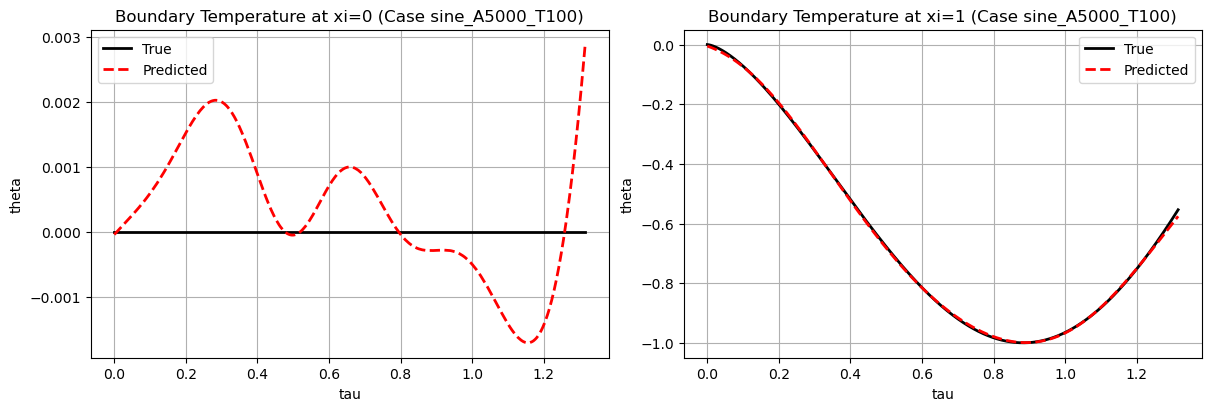

In [8]:
# Plot boundary temperature profiles (xi=0 and xi=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# xi=0 (left boundary)
axes[0].plot(tau, theta_true[0, :], 'k-', label='True', linewidth=2)
axes[0].plot(tau, theta_pred[0, :], 'r--', label='Predicted', linewidth=2)
axes[0].set_title(f'Boundary Temperature at xi=0 (Case {case_id})')
axes[0].set_xlabel('tau')
axes[0].set_ylabel('theta')
axes[0].legend()
axes[0].grid(True)

# xi=1 (right boundary)
axes[1].plot(tau, theta_true[-1, :], 'k-', label='True', linewidth=2)
axes[1].plot(tau, theta_pred[-1, :], 'r--', label='Predicted', linewidth=2)
axes[1].set_title(f'Boundary Temperature at xi=1 (Case {case_id})')
axes[1].set_xlabel('tau')
axes[1].set_ylabel('theta')
axes[1].legend()
axes[1].grid(True)

# Save the plot
boundary_plot_path = OUTDIR / f"boundary_profiles_{case_id}.png"
plt.savefig(boundary_plot_path, dpi=150, bbox_inches='tight')
print(f"Saved boundary profiles plot to: {boundary_plot_path}")

plt.show()


Saved temperature comparison plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1425\temperature_comparison_sine_A5000_T100.png


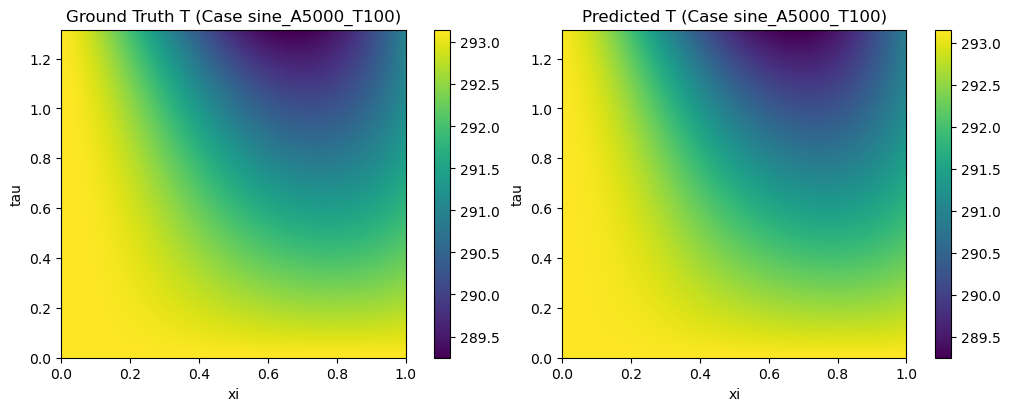

RMSE for case sine_A5000_T100: 1.7746e-03


In [9]:
# Quick comparison plot (ground truth vs prediction)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im0 = axes[0].imshow(T_true, aspect='auto', origin='lower',
                  extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[0].set_title(f'Ground Truth T (Case {case_id})')
axes[0].set_xlabel('xi')
axes[0].set_ylabel('tau')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(T_pred, aspect='auto', origin='lower',
                  extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[1].set_title(f'Predicted T (Case {case_id})')
axes[1].set_xlabel('xi')
axes[1].set_ylabel('tau')
plt.colorbar(im1, ax=axes[1])

# Save the plot
plot_path = OUTDIR / f"temperature_comparison_{case_id}.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Saved temperature comparison plot to: {plot_path}")

plt.show()

# Compute RMSE for this case
mse_case = np.mean((theta_pred - theta_true) ** 2)
rmse_case = np.sqrt(mse_case)
print(f"RMSE for case {case_id}: {rmse_case:.4e}")


## Validation & Metrics

Loaded checkpoint: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1425\2026_03_16_1425_best.pt
Validation logs:
  total: 8.6026e-05
  pde: 4.5083e-05
  ic: 5.8208e-06
  bc: 2.6480e-05
  bc_monitor: 0.0000e+00
  data: 8.6422e-06
  smooth: 0.0000e+00
Validation RMSE (data): 2.9398e-03
Saved validation scatter plot to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1425\validation_scatter.png


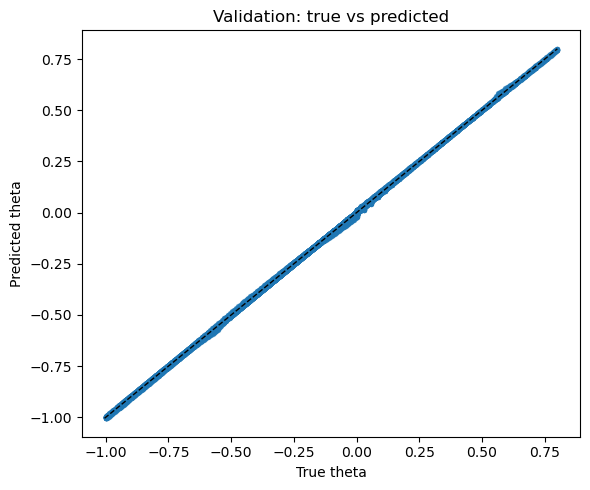

Saved validation metrics to: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\outputs\parametric\2026_03_16_1425\validation_metrics.txt


In [10]:
# example validation on held-out data
import src.train as train_mod
importlib.reload(train_mod)
from src.train import compute_losses_eval

# load checkpoint
ckpt = best_lbfgs_path if best_lbfgs_path is not None else None
if ckpt is not None and ckpt.exists():
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state["state_dict"])
    model.to(device)
    print(f"Loaded checkpoint: {ckpt}")

val_loss, val_logs = compute_losses_eval(model, val_batch, weights, create_graph=False)
print("Validation logs:")
for k, v in val_logs.items():
    print(f"  {k}: {v:.4e}")

if getattr(val_batch, "xi_data", None) is not None:
    model.eval()
    with torch.no_grad():
        X_val = torch.cat([val_batch.xi_data, val_batch.tau_data, val_batch.mu_data], dim=1).to(device)
        y_true = val_batch.theta_data.to(device)
        y_pred = model(X_val)
    mse = torch.mean((y_pred - y_true) ** 2).item()
    rmse = mse ** 0.5
    print(f"Validation RMSE (data): {rmse:.4e}")
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true.cpu().numpy(), y_pred.detach().cpu().numpy(), s=8, alpha=0.6)
    mn = min(y_true.min().item(), y_pred.min().item())
    mx = max(y_true.max().item(), y_pred.max().item())
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel("True theta")
    plt.ylabel("Predicted theta")
    plt.title("Validation: true vs predicted")
    plt.tight_layout()
    
    # Save the plot to OUTDIR
    plot_path = OUTDIR / "validation_scatter.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Saved validation scatter plot to: {plot_path}")
    
    plt.show()
else:
    print("No interior validation data present in `val_batch` to plot.")

# Save validation metrics to OUTDIR
metrics_path = OUTDIR / "validation_metrics.txt"
with open(metrics_path, 'w') as f:
    f.write("Validation Metrics\n")
    f.write("==================\n")
    for k, v in val_logs.items():
        f.write(f"{k}: {v:.6e}\n")
    f.write(f"rmse_data: {rmse:.6e}\n")
print(f"Saved validation metrics to: {metrics_path}")
    

## Upload and update

In [11]:
from src.experiment_logging import append_arch_search_result, compare_arch_to_best, ensure_arch_search_csv, load_best_arch_result
from sklearn.model_selection import train_test_split
import math
import subprocess

In [12]:
# Architecture experiment logger
results_csv = ROOT / "results" / "arch_search.csv"
ensure_arch_search_csv(str(results_csv))
baseline_best = load_best_arch_result(str(results_csv), metric="val_rmse_data")

def _safe_git_commit() -> str:
    try:
        out = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=ROOT,
            capture_output=True,
            text=True,
            check=True,
        )
        return out.stdout.strip()
    except Exception:
        return ""

def _first_linear(module):
    for m in module.modules():
        if isinstance(m, torch.nn.Linear):
            return m
    return None

def _activation_name(module):
    for m in module.modules():
        if isinstance(m, (torch.nn.Tanh, torch.nn.ReLU, torch.nn.GELU, torch.nn.Sigmoid, torch.nn.SiLU, torch.nn.ELU, torch.nn.LeakyReLU)):
            return m.__class__.__name__.lower()
    return "unknown"

first_linear = _first_linear(model)
n_neurons = int(first_linear.out_features) if first_linear is not None else None
n_linear = sum(1 for m in model.modules() if isinstance(m, torch.nn.Linear))
n_hidden_layers = max(n_linear - 1, 0)

adam_steps = int(globals().get("N_EPOCHS", globals().get("steps", 1000)))
lbfgs_iters = int(globals().get("max_iter", 500)) if "best_lbfgs_path" in globals() else 0
optimizer_name = "adam+lbfgs" if "best_lbfgs_path" in globals() else "adam"

current_result = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "git_commit": _safe_git_commit(),
    "seed": 42,
    "n_layers": n_hidden_layers,
    "n_neurons": n_neurons,
    "activation": _activation_name(model),
    "optimizer": optimizer_name,
    "epochs": adam_steps + lbfgs_iters,
    "lr": 1e-3,
    "n_colloc": int(globals().get("n_r", 50000)),
    "n_boundary": int(getattr(train_batch, "xi_bc", torch.empty(0, 1)).shape[0]),
    "n_initial": int(getattr(train_batch, "xi_ic", torch.empty(0, 1)).shape[0]),
    "n_data": int(getattr(train_batch, "xi_data", torch.empty(0, 1)).shape[0]),
    "loss_total": float(val_logs.get("total", math.nan)),
    "loss_pde": float(val_logs.get("pde", math.nan)),
    "loss_ic": float(val_logs.get("ic", math.nan)),
    "loss_bc": float(val_logs.get("bc", math.nan)),
    "loss_data": float(val_logs.get("data", math.nan)),
    "val_rmse_data": float(rmse),
    "val_pde_loss": float(val_logs.get("pde", math.nan)),
}

improved, reason = compare_arch_to_best(current_result, baseline_best)
append_arch_search_result(str(results_csv), current_result)

def _fmt(x):
    try:
        v = float(x)
        if math.isfinite(v):
            return f"{v:.6e}"
    except Exception:
        pass
    return "nan"

print()
print("Architecture comparison:")
if baseline_best is None:
    print("Baseline best metrics: none (first recorded run)")
else:
    print(
        "Baseline best metrics: "
        f"val_rmse_data={_fmt(baseline_best.get('val_rmse_data'))}, "
        f"val_pde_loss={_fmt(baseline_best.get('val_pde_loss'))}, "
        f"loss_total={_fmt(baseline_best.get('loss_total'))}"
    )

print(
    "Current metrics: "
    f"val_rmse_data={_fmt(current_result.get('val_rmse_data'))}, "
    f"val_pde_loss={_fmt(current_result.get('val_pde_loss'))}, "
    f"loss_total={_fmt(current_result.get('loss_total'))}"
)
print(("? IMPROVED: " if improved else "? NOT IMPROVED: ") + reason)
print(f"Logged run to {results_csv}")




Architecture comparison:
Baseline best metrics: val_rmse_data=3.210986e-03, val_pde_loss=2.509391e-05, loss_total=5.884074e-05
Current metrics: val_rmse_data=2.939769e-03, val_pde_loss=4.508330e-05, loss_total=8.602647e-05
? NOT IMPROVED: PDE guardrail failed: 4.508330e-05 vs baseline 2.509391e-05 (79.66% worse).
Logged run to c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\results\arch_search.csv


In [13]:
log_path = Path(ROOT, "results", "experiment_log.csv")
if log_path.exists():
    log_df = pd.read_csv(log_path)
    display(log_df.tail(5))
else:
    print(f"No log found at {log_path}")

,experiment_id,date_time_utc,commit_hash,python_version,torch_version,cuda_available,device,random_seed,case_id,data_paths,...,final_total_loss,final_pde_loss,final_bc_loss,final_ic_loss,final_data_loss,final_grad_norm,l2_error_temperature,max_abs_error,relative_l2_error,r2_score
0,20260216T153205Z_const_5000_596ff96_19ff91,2026-02-16T15:32:05.004343+00:00,596ff96,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.001084,0.000171,0.000001,0.000576,0.000336,NaN,NaN,NaN,NaN,NaN
1,20260216T161524Z_const_5000_775133c_437d6a,2026-02-16T16:15:24.247973+00:00,775133c,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002162,0.000349,0.000325,0.001451,0.000037,NaN,NaN,NaN,NaN,NaN
2,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
3,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
